In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\heman\Downloads\data_science_job.csv")

In [9]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [11]:
((df.isnull().sum())/len(df))*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [22]:
column_can_be_deleted=[]
for column in df.columns:
    if ((df[column].isnull().sum()/len(df[column]))*100 >0 and (df[column].isnull().sum()/len(df[column]))*100 < 4):
        column_can_be_deleted.append(column)

In [23]:
column_can_be_deleted

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [25]:
df[column_can_be_deleted].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
17634,0.897,NaN,Masters,9.0,42.0
4907,0.920,no_enrollment,Graduate,19.0,25.0
19050,0.920,Full time course,Graduate,9.0,NaN
2005,0.926,no_enrollment,Masters,19.0,48.0
11738,0.743,Part time course,Masters,11.0,46.0


In [26]:
new_df=df[column_can_be_deleted].dropna()

In [27]:
new_df

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


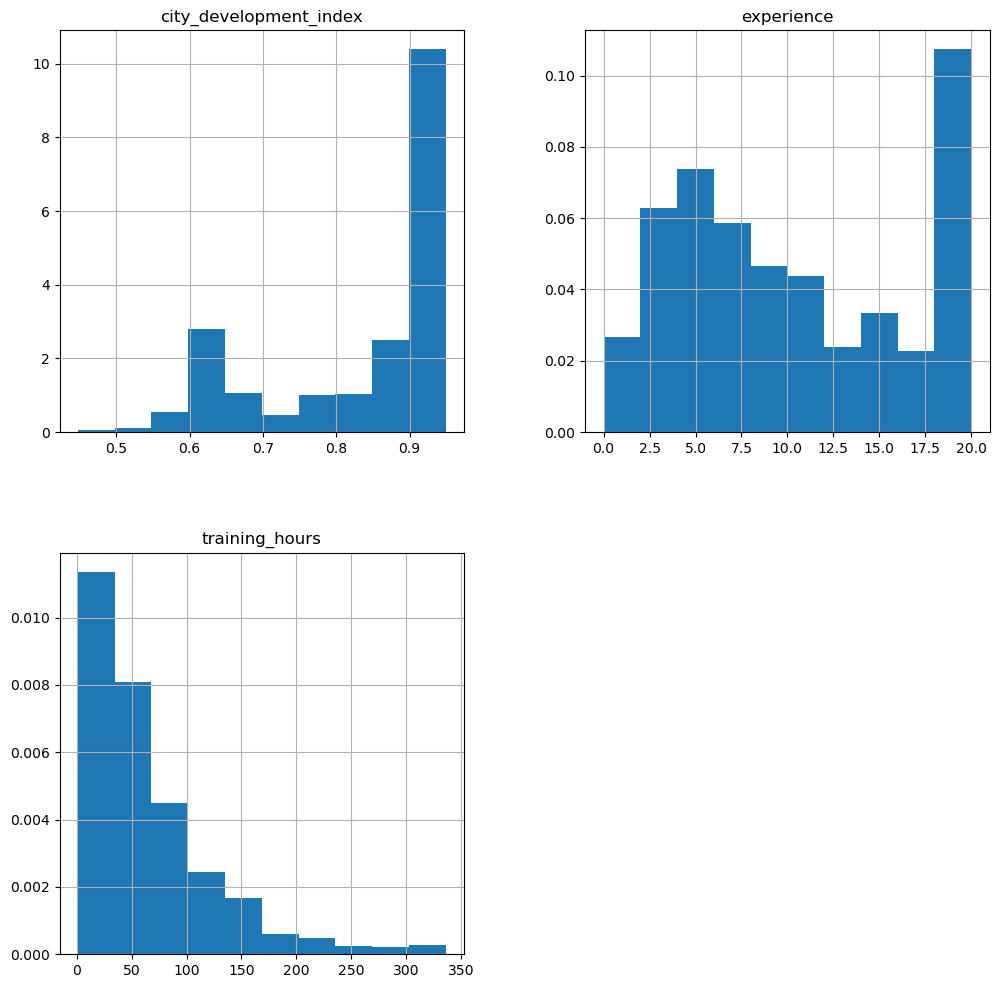

In [29]:
new_df.hist(bins=10,density=True,figsize=(12,12))
plt.show()

<AxesSubplot:>

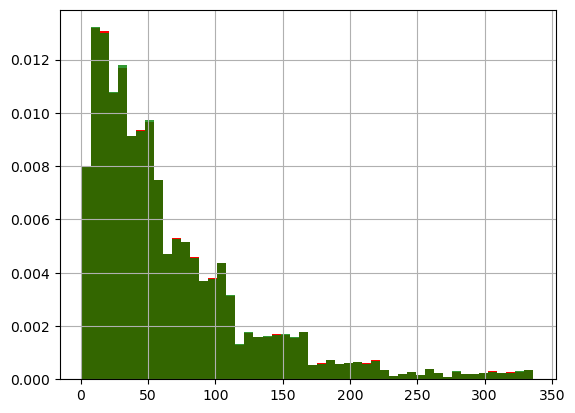

In [36]:
fig=plt.figure()
ax=fig.add_subplot(111)
df["training_hours"].hist(bins=50,ax=ax,density=True,color="red")
new_df["training_hours"].hist(bins=50,ax=ax,density=True,color="green",alpha=0.8)

<AxesSubplot:ylabel='Density'>

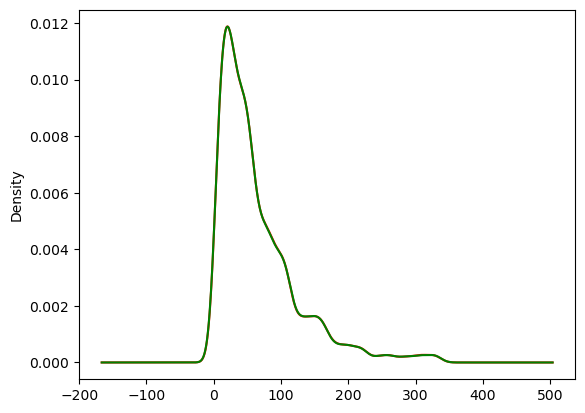

In [37]:
fig=plt.figure()
ax=fig.add_subplot(111)

df["training_hours"].plot.density(color="red")
new_df["training_hours"].plot.density(color="green")

<AxesSubplot:>

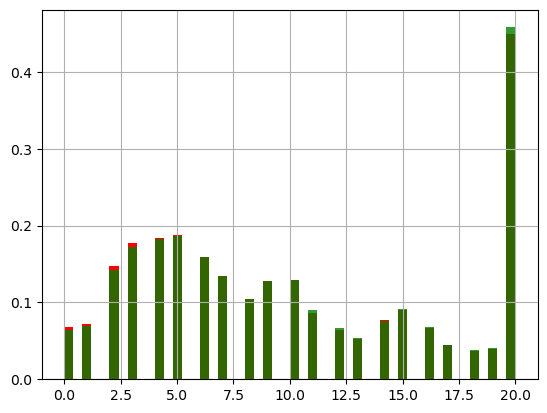

In [38]:
fig=plt.figure()
ax=fig.add_subplot(111)
df["experience"].hist(bins=50,ax=ax,density=True,color="red")
new_df["experience"].hist(bins=50,ax=ax,density=True,color="green",alpha=0.8)

<AxesSubplot:ylabel='Density'>

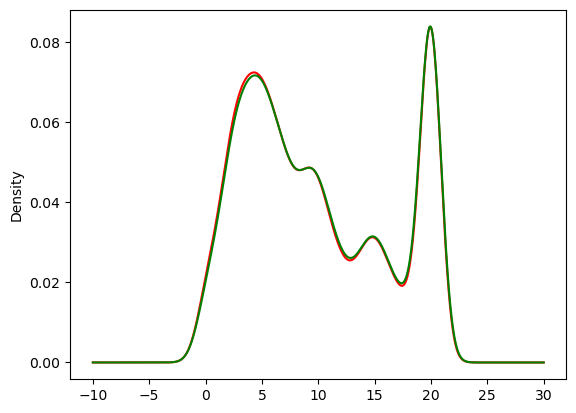

In [39]:
fig=plt.figure()
ax=fig.add_subplot(111)

df["experience"].plot.density(color="red")
new_df["experience"].plot.density(color="green")

<AxesSubplot:>

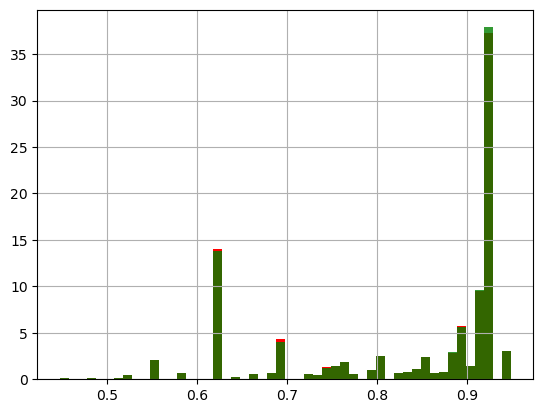

In [40]:
fig=plt.figure()
ax=fig.add_subplot(111)
df["city_development_index"].hist(bins=50,ax=ax,density=True,color="red")
new_df["city_development_index"].hist(bins=50,ax=ax,density=True,color="green",alpha=0.8)

<AxesSubplot:ylabel='Density'>

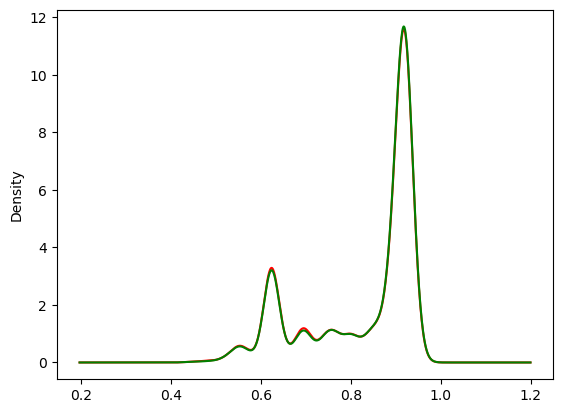

In [41]:
fig=plt.figure()
ax=fig.add_subplot(111)

df["city_development_index"].plot.density(color="red")
new_df["city_development_index"].plot.density(color="green")